# Valutazione e confronto: KDE vs GMM vs Normalizing Flow

## Metrica di valutazione

Per confrontare i tre metodi di density estimation usiamo il **tempo di primo rilevamento**: il numero di timestep che trascorrono tra l'inizio dell'anomalia (primo punto con `anomaly=1`) e il primo timestep in cui il modello lancia un allarme (score sotto soglia). Un ritardo minore indica un modello più reattivo.

La soglia è calibrata al **5° percentile** degli score sul training set (dati normali), così da garantire un tasso di falsi positivi del 5% in condizioni normali.

In [13]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Risultati dai tre modelli
data_kde = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,15,0,0,0,0,0,0,1,0]
data_gmm = [1,0,3,42,2,8,25,0,38,38,5,0,46,7,2,4,0,34,18,21,11,2,2,1,2,4,0,9,3,0,0,1,1,2]
data_nf  = [0,0,0,0,0,0,4,0,0,0,0,0,1,0,2,0,0,1,0,0,1,0,1,0,2,0,0,0,0,0,0,1,1,2]

files = [
    "valve1/0.csv","valve1/1.csv","valve1/10.csv","valve1/11.csv",
    "valve1/12.csv","valve1/13.csv","valve1/14.csv","valve1/15.csv",
    "valve1/2.csv","valve1/3.csv","valve1/4.csv","valve1/5.csv",
    "valve1/6.csv","valve1/7.csv","valve1/8.csv","valve1/9.csv",
    "valve2/0.csv","valve2/1.csv","valve2/2.csv","valve2/3.csv",
    "other/1.csv","other/10.csv","other/11.csv","other/12.csv",
    "other/13.csv","other/14.csv","other/2.csv","other/3.csv",
    "other/4.csv","other/5.csv","other/6.csv","other/7.csv",
    "other/8.csv","other/9.csv"
]

df = pd.DataFrame({"file": files, "KDE": data_kde, "GMM": data_gmm, "NF": data_nf})
df["category"] = df["file"].apply(lambda x: x.split("/")[0])

print("Ritardo medio per modello")
print(f"KDE: {np.mean(data_kde):.1f} timestep")
print(f"GMM: {np.mean(data_gmm):.1f} timestep")
print(f"NF:  {np.mean(data_nf):.1f} timestep")

Ritardo medio per modello
KDE: 0.5 timestep
GMM: 9.8 timestep
NF:  0.5 timestep


## Risultati globali

Il barplot mostra il ritardo di primo rilevamento per ciascun file e modello. KDE e NF sono quasi sempre immediati (ritardo 0), mentre il GMM mostra ritardi significativi su diversi file, con picchi fino a 46 timestep.

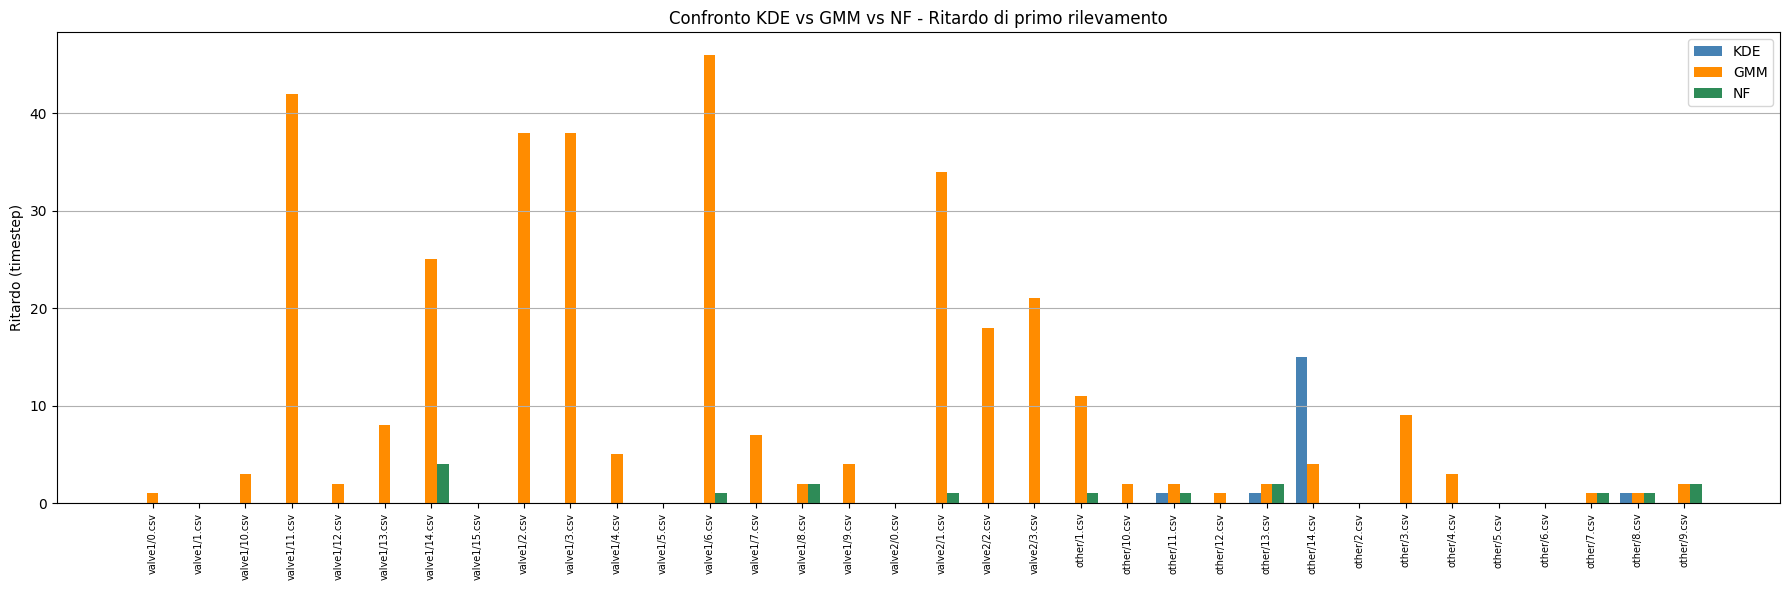

In [14]:
x = np.arange(len(files))
width = 0.25

fig, ax = plt.subplots(figsize=(18, 6))
ax.bar(x - width, data_kde, width, label="KDE", color="steelblue")
ax.bar(x, data_gmm, width, label="GMM", color="darkorange")
ax.bar(x + width, data_nf, width, label="NF", color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels(files, rotation=90, fontsize=7)
ax.set_ylabel("Ritardo (timestep)")
ax.set_title("Confronto KDE vs GMM vs NF - Ritardo di primo rilevamento")
ax.legend()
ax.grid(axis="y")
plt.tight_layout()
plt.show()

Il boxplot e il violin plot mostrano la distribuzione complessiva dei ritardi. Il GMM ha mediana più alta e varianza molto maggiore rispetto a KDE e NF, che rimangono concentrati intorno a 0.

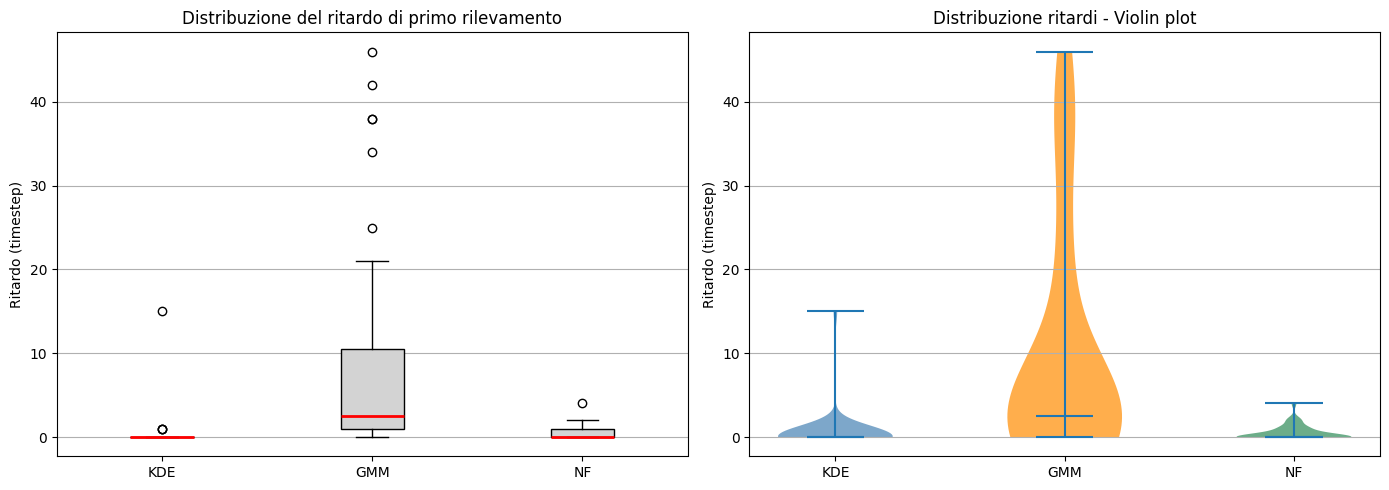

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
axes[0].boxplot([data_kde, data_gmm, data_nf], tick_labels=["KDE", "GMM", "NF"],
                patch_artist=True,
                boxprops=dict(facecolor="lightgray"),
                medianprops=dict(color="red", linewidth=2))
axes[0].set_ylabel("Ritardo (timestep)")
axes[0].set_title("Distribuzione del ritardo di primo rilevamento")
axes[0].grid(axis="y")

# Violin plot
parts = axes[1].violinplot([data_kde, data_gmm, data_nf], positions=[1, 2, 3],
                            showmedians=True, showextrema=True)
colors = ["steelblue", "darkorange", "seagreen"]
for pc, color in zip(parts["bodies"], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(["KDE", "GMM", "NF"])
axes[1].set_ylabel("Ritardo (timestep)")
axes[1].set_title("Distribuzione ritardi - Violin plot")
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

## Analisi per categoria

Le anomalie del dataset SKAB si dividono in tre categorie: chiusura della valvola 1 (`valve1`), chiusura della valvola 2 (`valve2`), e altri scenari (`other`). Il GMM mostra ritardi maggiori su valve1 e valve2, dove le anomalie sono più graduali. KDE e NF rimangono stabili su tutte le categorie.

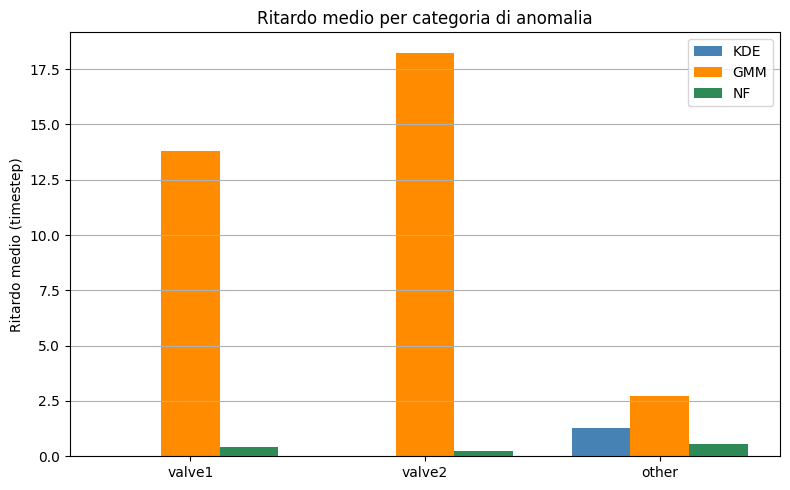

In [16]:
categories = ["valve1", "valve2", "other"]
x = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
for i, (model, color) in enumerate([("KDE", "steelblue"), ("GMM", "darkorange"), ("NF", "seagreen")]):
    means = [df[df["category"] == cat][model].mean() for cat in categories]
    ax.bar(x + i*width, means, width, label=model, color=color)

ax.set_xticks(x + width)
ax.set_xticklabels(categories)
ax.set_ylabel("Ritardo medio (timestep)")
ax.set_title("Ritardo medio per categoria di anomalia")
ax.legend()
ax.grid(axis="y")
plt.tight_layout()
plt.show()

## Confronto degli score su un caso rappresentativo

Visualizziamo gli score dei tre modelli su `valve1/1.csv`, un file con anomalia graduale da chiusura valvola. I tre subplot mostrano come cambia il profilo di log-likelihood di ciascun modello in corrispondenza della zona anomala (evidenziata in rosso). Gli score sono poi normalizzati tra 0 e 1 per confrontarli sullo stesso grafico.

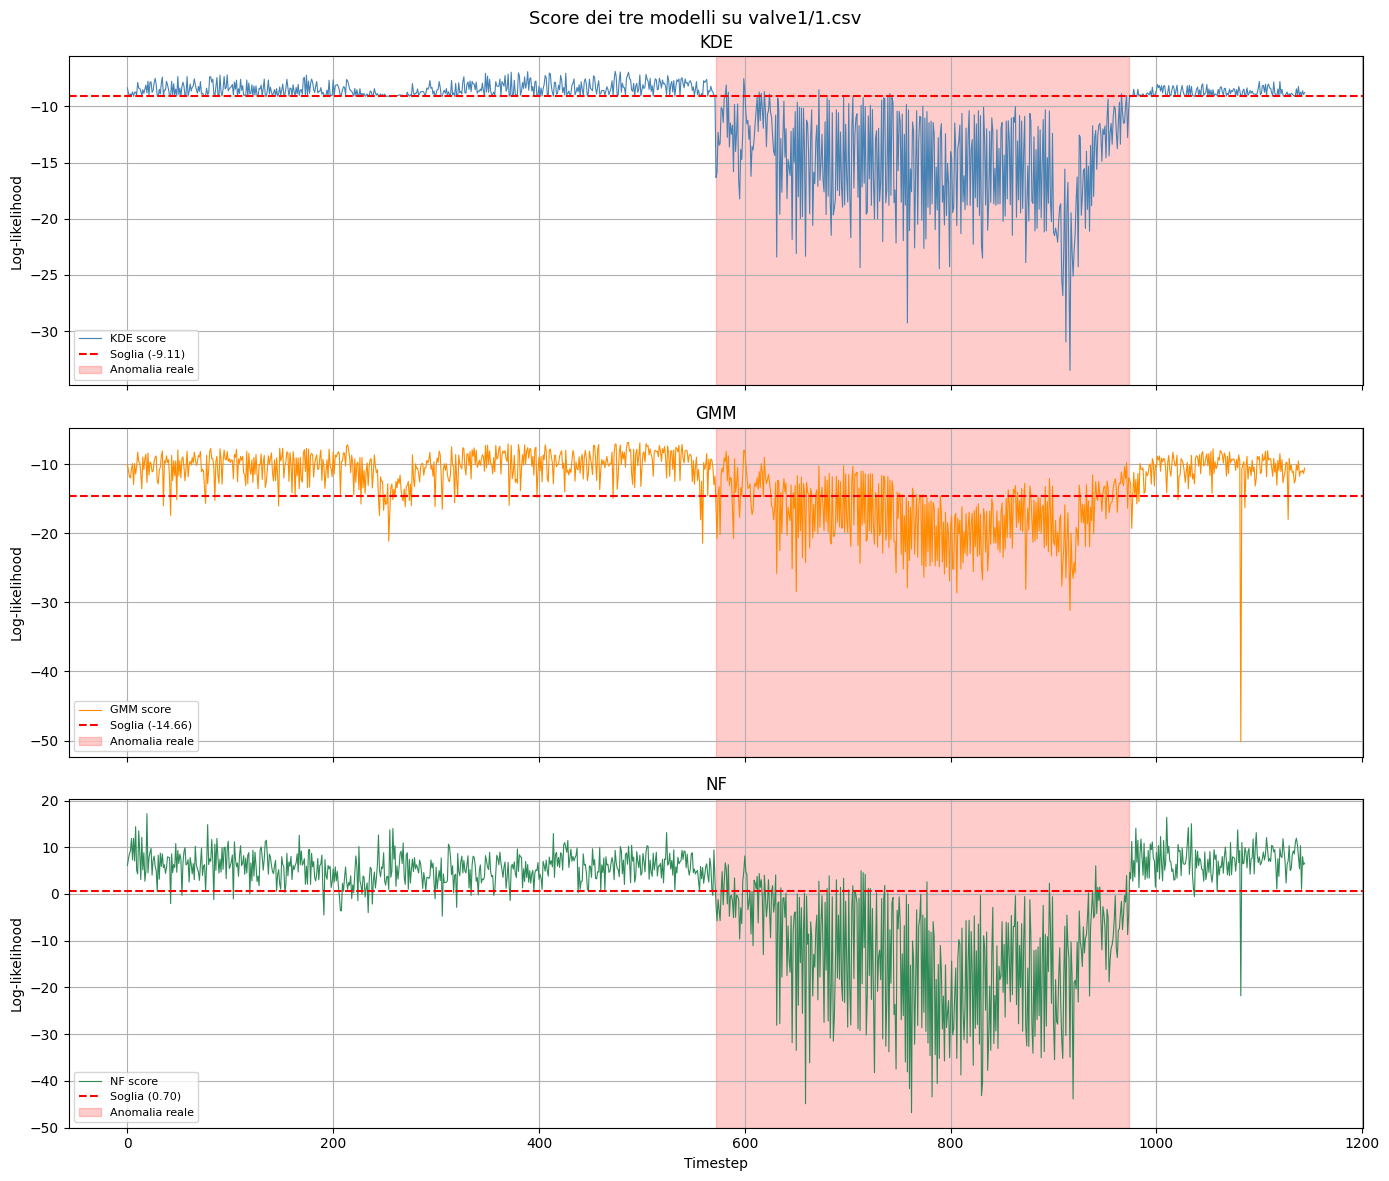

In [17]:
from sklearn.neighbors import KernelDensity
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import torch
import normflows as nf
import pickle

with open("preprocessing.pkl", "rb") as f:
    prep = pickle.load(f)
features = prep["features"]
all_files = prep["all_files"]

fpath = all_files[1]  # valve1/1.csv
df_test = pd.read_csv(fpath, sep=";")
df_normal = df_test[df_test["anomaly"] == 0]

scaler = StandardScaler()
X_train = scaler.fit_transform(df_normal[features].values)
X_all = scaler.transform(df_test[features].values)

# KDE
kde = KernelDensity(kernel="gaussian", bandwidth=0.5456)
kde.fit(X_train)
scores_kde = kde.score_samples(X_all)
thr_kde = np.percentile(kde.score_samples(X_train), 5)

# GMM
gmm = GaussianMixture(n_components=3, random_state=42, n_init=5, covariance_type="diag")
gmm.fit(X_train)
scores_gmm = gmm.score_samples(X_all)
thr_gmm = np.percentile(gmm.score_samples(X_train), 5)

# NF
X_tensor = torch.tensor(X_train, dtype=torch.float32)
dim = X_train.shape[1]
flows = []
for _ in range(8):
    flows.append(nf.flows.AutoregressiveRationalQuadraticSpline(dim, 2, 64))
    flows.append(nf.flows.LULinearPermute(dim))
q0 = nf.distributions.DiagGaussian(dim, trainable=False)
model_nf = nf.NormalizingFlow(q0=q0, flows=flows)
optimizer = torch.optim.Adam(model_nf.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)
for epoch in range(500):
    optimizer.zero_grad()
    loss = model_nf.forward_kld(X_tensor)
    torch.nn.utils.clip_grad_norm_(model_nf.parameters(), max_norm=1.0)
    loss.backward()
    optimizer.step()
    scheduler.step()
model_nf.eval()
with torch.no_grad():
    scores_nf = model_nf.log_prob(torch.tensor(X_all, dtype=torch.float32)).numpy()
    thr_nf = np.percentile(model_nf.log_prob(X_tensor).numpy(), 5)

anomaly_idx = df_test[df_test["anomaly"] == 1].index

# Subplot separati
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
for ax, scores, thr, label, color in zip(
    axes,
    [scores_kde, scores_gmm, scores_nf],
    [thr_kde, thr_gmm, thr_nf],
    ["KDE", "GMM", "NF"],
    ["steelblue", "darkorange", "seagreen"]
):
    ax.plot(scores, color=color, label=f"{label} score", linewidth=0.8)
    ax.axhline(y=thr, color="red", linestyle="--", label=f"Soglia ({thr:.2f})")
    ax.axvspan(anomaly_idx[0], anomaly_idx[-1], alpha=0.2, color="red", label="Anomalia reale")
    ax.set_ylabel("Log-likelihood")
    ax.set_title(f"{label}")
    ax.legend(fontsize=8)
    ax.grid(True)
axes[-1].set_xlabel("Timestep")
plt.suptitle("Score dei tre modelli su valve1/1.csv", fontsize=13)
plt.tight_layout()
plt.show()

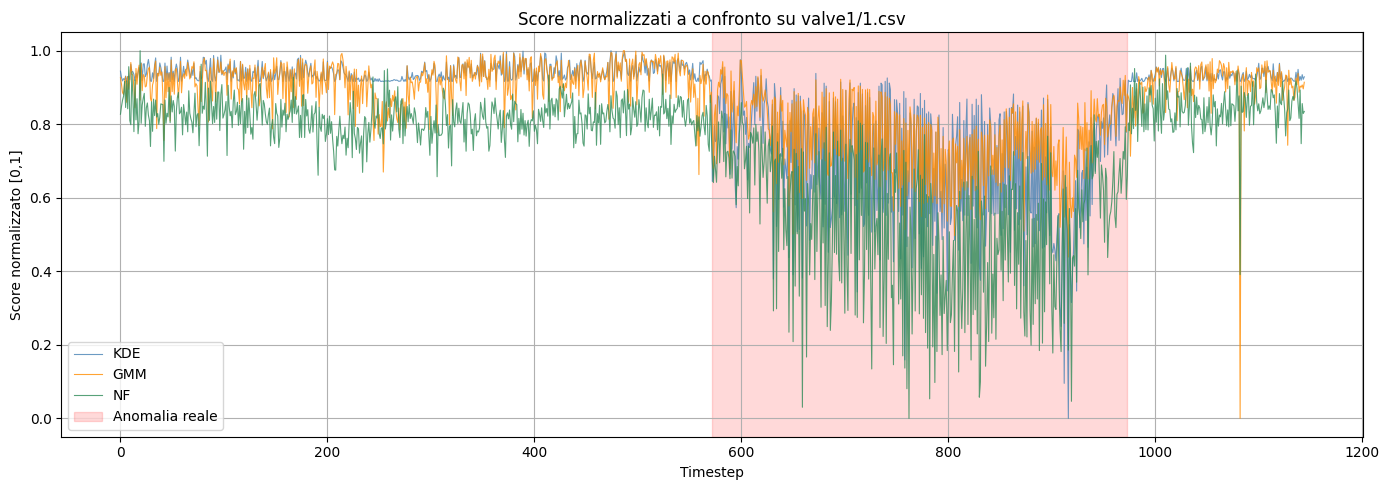

In [18]:
# Score normalizzati sovrapposti
def normalize(x):
    return (x - x.min()) / (x.max() - x.min())

plt.figure(figsize=(14, 5))
plt.plot(normalize(scores_kde), color="steelblue", label="KDE", linewidth=0.8, alpha=0.8)
plt.plot(normalize(scores_gmm), color="darkorange", label="GMM", linewidth=0.8, alpha=0.8)
plt.plot(normalize(scores_nf), color="seagreen", label="NF", linewidth=0.8, alpha=0.8)
plt.axvspan(anomaly_idx[0], anomaly_idx[-1], alpha=0.15, color="red", label="Anomalia reale")
plt.xlabel("Timestep")
plt.ylabel("Score normalizzato [0,1]")
plt.title("Score normalizzati a confronto su valve1/1.csv")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()